###### Content under Creative Commons Attribution license CC-BY 4.0, code under BSD 3-Clause License © 2022  by D. Koehn, T. Meier and J. Stampa, notebook style sheet by L.A. Barba, N.C. Clementi

# Digital Signal Processing in Geophysics 

## Chapter 5 Signal Stacking

In this notebook, we apply the Slant Stack and the phase velocity frequency spectrum to a field dataset.

### Field Dataset

Now that we have tested our codes for the slant stack and the phase velocity frequency spectrum on simple synthetic problems, the next step is to import a field dataset and apply our codes to it. 

The SH dataset was recorded during an archaeogeophysical field course in Slovakia. It was the first field dataset to which we applied a seismic SH full-waveform inversion (FWI). I have summarized further details on the motivation for the measurement, the data acquisition, and the FWI results in [this video](https://youtu.be/afVsvdfMWLo). The topic is discussed in greater detail in this paper by [Dokter et al. (2017)](https://www.researchgate.net/publication/317336182_Full-waveform_inversion_of_SH-_and_Love-wave_data_in_near-surface_prospecting).

In [1]:
# Import Python libraries
# -----------------------
#%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np

First, we need to unzip the compressed field data set in the `data` folder.

To import the field data, the `create shotgather` function simply needs to be slightly modified. The data is imported from an ASCII file that already contains the shotgather in matrix form. Important acquisition parameters, such as the distance between the receivers and the sampling interval, are defined in the notebook.

In [2]:
def create_shotgather():
    
    # Load Cachtice SH-data (profile 2)
    TT = np.loadtxt('data/Cachtice_prof2_y.shot1', delimiter='\t', skiprows=0, unpack='True')
    nx, nt = np.shape(TT) # estimate nt and nx
    
    # Define acquisition parameters
    dx = 0.5                 # spatial geophone sampling [m]
    xmax = nx * dx           # maximum offset [m]
    
    dt = 1.25e-4             # time sampling [s]    
    tmax = nt * dt           # maximum recording time [s]
    
    # Define offsets and t
    x = np.arange(0, xmax, dx) # offsets [m]
    t = np.arange(0, tmax, dt) # time [s]
    
    return x,t,TT

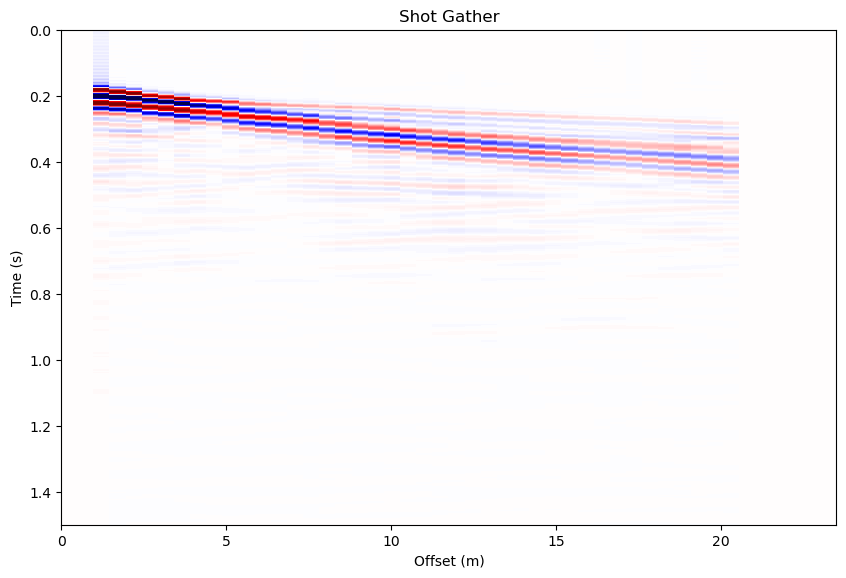

In [5]:
x,t,TT = create_shotgather()

# Initialize Plots
plt.figure(figsize=(10,7))
    
# Plot shot gather
clip=5e0
plt.imshow(TT.T, cmap=plt.cm.seismic, interpolation='none', vmin=-clip, vmax=clip, 
                extent=[np.min(x),np.max(x),np.max(t),np.min(t)],aspect=1e1)
plt.xlabel('Offset (m)')
plt.ylabel('Time (s)')
title = r'Shot Gather'
plt.title(title);

Notable events in the shot gather include the direct wave, a refracted wave, and a Love-type surface wave. In addition, faint reflections and diffractions are visible in the data. 

### NMO Correction 

In the next step, the **Normal Move Out (NMO)** of linear events (direct and refracted waves) for various test velocities $vstack$ is corrected using the formula 

\begin{equation}
\Delta t_{NMO} = - \frac{x}{vstack}\notag
\end{equation}

and the corrected seismic traces are stacked according to 

\begin{equation}
\mbox{stack}(t) = \frac{1}{M} \sum_{i=1}^M x_i(t+\Delta t_{NMO}). \notag
\end{equation}

In [6]:
def NMO_corr(vstack,stackcorr):
    
    # create data
    x,t,TT = create_shotgather()
    
    # Define parameters
    nx = len(x)
    nt = len(t)
    dt = t[1]-t[0]
    
    if(stackcorr==True):
        
        # NMO correction by dtNMO = - offset / vstack 
        # --------------------------------------------------------
        TTc = np.zeros((nx,nt))  # initialize corrected shot gather
        tstack = (x / vstack)    # traveltime [s]
        nc = (tstack/dt)         # traveltime [sample#]
        nc = nc.astype(np.int32) # convert floats to integers
    
        for i in range(0,nx):
            for j in range(0,nt):
            
                if((j+nc[i]) < nt):
                    TTc[i,j] = TT[i,j+nc[i]]
    
        
        TT = TTc
        
    # Initialize Plots
    plt.figure(figsize=(10,5))
    
    plt.subplot(121)
    
    # Plot shot gather
    clip=5e0
    plt.imshow(TT.T, cmap=plt.cm.seismic, interpolation='none', vmin=-clip, vmax=clip, 
                   extent=[np.min(x),np.max(x),np.max(t),np.min(t)],aspect=2e1)
    plt.xlabel('Offset (m)')
    plt.ylabel('Time (s)')
    title = r'Shot Gather'
    plt.title(title)
    
    plt.subplot(122)
    
    # Stack data along offsets
    stack = np.sum(TT,0) / nx
    
    # Plot stack
    plt.plot(np.flip(stack), np.flip(t), 'b')
    plt.xlabel('Stack Amplitude ()')
    plt.title('Stack')
    plt.xlim(-1.,1.)
    plt.ylim(np.min(t),np.max(t))
    plt.gca().invert_yaxis()

In [8]:
interactive_plot = interactive(NMO_corr, vstack=(10., 400., 10.), stackcorr=False )
output = interactive_plot.children[-1]
output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=200.0, description='vstack', max=400.0, min=10.0, step=10.0), Checkbox…

For the direct wave, we obtain a reasonable NMO correction at $vstack_d=100\; m/s$, for the Love wave at approximately $vstack_l = 130\; m/s$, and for the refracted wave at $vstack_r = 220\; m/s$.

### Slant Stack 

Based on the `NMO_corr` function, we can program a function that calculates the **slant stack** of a shot gather. To do this, we simply apply the NMO correction for different stacking velocities $vstack$ to the shot gather and save the stacked stacks for each velocity. If we plot the times against the stacks, we obtain the slant stack ...

In [25]:
def slant_stack():
    
    # create data
    x,t,TT = create_shotgather()
    
    # Define parameters
    nx = len(x)
    nt = len(t)
    dt = t[1]-t[0]
    
    # Compute Slant Stack
    # -------------------
    
    # define array for stacking velocities
    vstack = np.arange(10.,500.,10.)
    nv = len(vstack) # number of tested velocities
    
    # initialize slant stack with zeros
    sstack = np.zeros((nv,nt))
    
    # loop over velocities
    for k in range(0,nv) :
        
        # NMO correction by dtNMO = - offset / vstack 
        TTc = np.zeros((nx,nt))    # initialize corrected shot gather
        tstack = (x / vstack[k])   # traveltime [s]
        nc = (tstack/dt)           # traveltime [sample#]
        nc = nc.astype(np.int32)   # convert floats to integers
    
        for i in range(0,nx):
            for j in range(0,nt):
            
                if((j+nc[i]) < nt):
                    TTc[i,j] = TT[i,j+nc[i]]
    
        # Stack NMO corrected data
        stack = np.sum(TTc,0) / nx
            
    
        # update slant stack
        sstack[k,:] = stack[:]
    
    
    # Initialize Plots
    plt.figure(figsize=(8,16))
    
    # Plot slant stack
    plt.imshow(sstack.T, cmap=plt.cm.seismic, interpolation='none', 
                   extent=[np.min(vstack),np.max(vstack),np.max(t),np.min(t)],aspect=2e2)
    plt.xlabel('vstack (m/s)')
    plt.ylabel(r'$\tau$ (s)')
    title = r'Slant Stack'
    plt.title(title)
    
    return sstack

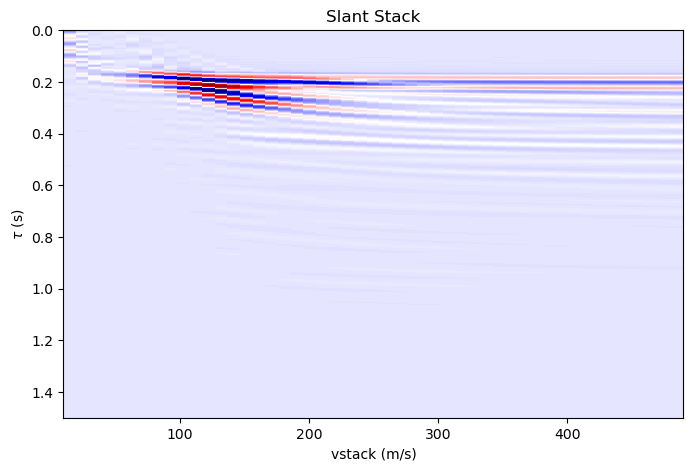

In [26]:
sstack = slant_stack()

Based on our “interactive” velocity determination using the comparison between the shot gather and the stack in the previous section, we can interpret the maxima in the slant stack accordingly. Direct wave $vstack_d=100\; m/s$, Love wave $vstack_l = 130\; m/s$, and the refracted wave $vstack_r = 220\; m/s$.

### Phase-velocity frequency spectra

If we compute the Fourier transform of the time axis, we obtain the **phase-velocity frequency spectrum**. This can be easily implemented in our Slant-Stack code ...

In [27]:
def pf_spec():
    
    # create data
    x,t,TT = create_shotgather()
    
    # Define parameters
    nx = len(x)
    nt = len(t)
    dt = t[1]-t[0]
    
    # Compute Slant Stack
    # -------------------
    
    # define array for stacking velocities
    vstack = np.arange(10.,300.,10.)
    nv = len(vstack) # number of tested velocities
    
    # initialize slant stack with zeros
    sstack = np.zeros((nv,nt))
    
    # loop over velocities
    for k in range(0,nv) :
        
        # NMO correction by dtNMO = - offset / vstack 
        TTc = np.zeros((nx,nt))    # initialize corrected shot gather
        tstack = (x / vstack[k])   # traveltime [s]
        nc = (tstack/dt)           # traveltime [sample#]
        nc = nc.astype(np.int32)   # convert floats to integers
    
        for i in range(0,nx):
            for j in range(0,nt):
            
                if((j+nc[i]) < nt):
                    TTc[i,j] = TT[i,j+nc[i]]
    
        # Stack NMO corrected data
        stack = np.sum(TTc,0) / nx
            
        # update slant stack
        sstack[k,:] = stack[:]
    
    # Compute pf-spectrum
    # -------------------
    
    # Fourier transform slant stack along the time axis
    pf = np.fft.fft(sstack)
    
    # Normalize by length of the time series
    pf = pf / (nt*dt)
    
    # estimate frequencies    
    freq = np.fft.fftfreq(nt, d=dt)
    
    # Initialize Plots
    plt.figure(figsize=(8,8))
    
    # Plot pf spectrum
    levels = np.linspace(0., np.max(np.abs(pf)), num=1000)
    plt.contourf(freq,vstack,np.abs(pf),levels=levels,cmap='magma')
    
    plt.ylabel('Phase velocity vstack (m/s)')
    plt.xlabel(r'Frequency (Hz)')
    title = r'Phasevelocity-Frequency Spectrum'
    plt.title(title)
    plt.xlim(0.,60.)

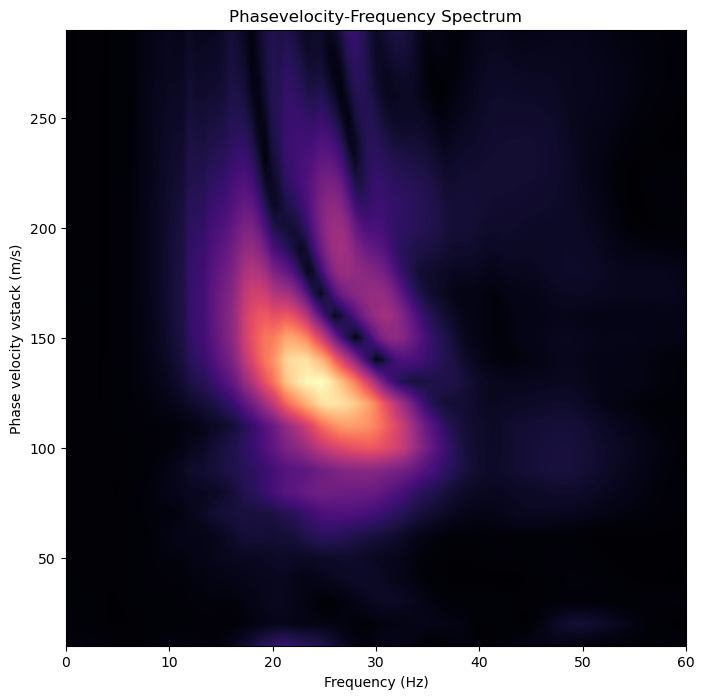

In [28]:
pf_spec()

The dominant signal in the phase velocity-frequency spectrum is the Love wave, whose velocity varies from 250 m/s to 100 m/s in the frequency range between 10 Hz and 30 Hz. Since the lower-frequency components of the Love wave penetrate deeper into the subsurface than the higher-frequency ones, we can conclude that the S-wave velocity in the subsurface increases accordingly. The following figure shows the result of the seismic SH full waveform inversion:

<img src="fig/Cachtice_profile2_FWI.jpg" style="width: 800px;"/>

As can be seen, a simple interpretation of the phase velocity frequency spectrum can already provide a relatively good representation of the subsurface’s general structure.

## Summary:

- Following the synthetic tests, we were able to apply the Slant Stack and the phase velocity frequency spectrum to a field dataset with a few minor modifications to the code.